# Feature Selection GAS

In [157]:
stock_code = "GAS"

In [158]:
stock_code = str.lower(stock_code)

## Install libraries

In [159]:
# !pip install -r ../../requirements.txt

## Import libraries

In [160]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
    summarize_feature_importances,
    plot_final_feature_importances,
    plot_feature_correlation_heatmap,
    drop_low_importance_correlated_features,
    get_important_features_df,
    get_feature_correlation_df,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [161]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [162]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [163]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [164]:
normalized_importances_dict = {}

In [165]:
output_column_name = "close"

In [166]:
train_ratio = DEFAULT_TRAIN_RATIO
input_window_size = DEFAULT_INPUT_WINDOW_SIZE
forecast_horizon_size = DEFAULT_FORECAST_HORIZON_SIZE

## Load data

In [167]:
df = database_driver.select(
    schema_name=Schema.ENTERPRISE.value,
    table_name=f"unified_{stock_code}",
)
df = cast_columns_to_float(df)

In [168]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,3.0,1.0,0.0,2.0,5.000000e-01,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,4.0,1.0,0.0,2.0,5.000000e-01,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,4.0,1.0,0.0,2.0,5.000000e-01,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,4.0,1.0,0.0,2.0,5.000000e-01,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,4.0,1.0,0.0,2.0,5.000000e-01,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,2025-06-19,7.835495,107.063333,939.562667,577.002000,73.323667,319.871000,223.049667,224.155333,2781.410333,...,3.0,1.0,0.0,3.0,1.224647e-16,-1.000000,0.433884,-0.900969,0.213521,-0.976938
3265,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,3.0,1.0,0.0,3.0,1.224647e-16,-1.000000,-0.433884,-0.900969,0.196673,-0.980469
3266,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000,0.000000,1.000000,0.145799,-0.989314
3267,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000,0.974928,-0.222521,0.111659,-0.993747


In [169]:
# Sort by date or time index if available
if "date" in df.columns:
    df = df.sort_values("date").reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

# --- Adjusted split index logic ---
split_index = ceil(len(df) * train_ratio)
split_index -= input_window_size  # ensure full input window fits

# Make split_index divisible by forecast_horizon_size
remainder = split_index % forecast_horizon_size
if remainder != 0:
    split_index -= remainder

# Guard against invalid split index
if split_index <= 0 or split_index >= len(df):
    raise ValueError(
        f"Adjusted split_index ({split_index}) is invalid for data length {len(df)}"
    )

# Add back input windwo size to split_index
split_index += input_window_size
split_index = int(split_index)
split_index

2940

In [170]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [171]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,3.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,2024-02-26,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,2024-02-27,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,2024-02-28,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,2024-02-29,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,...,5.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


In [172]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2024-03-04,5.974505,92.653983,563.353548,615.483871,41.935484,219.354839,228.387097,206.451613,1916.129032,...,1.0,1.0,0.0,2.0,1.000000e+00,6.123234e-17,0.000000,1.000000,0.891981,0.452072
1,2024-03-05,5.962857,92.666454,566.691935,619.354839,42.419355,224.193548,235.483871,208.064516,1945.161290,...,1.0,1.0,0.0,2.0,1.000000e+00,6.123234e-17,0.781831,0.623490,0.899631,0.436651
2,2024-03-06,5.951209,92.678924,570.030323,623.225806,42.903226,229.032258,242.580645,209.677419,1974.193548,...,1.0,1.0,0.0,2.0,1.000000e+00,6.123234e-17,0.974928,-0.222521,0.907014,0.421101
3,2024-03-07,5.939560,92.691394,573.368710,627.096774,43.387097,233.870968,249.677419,211.290323,2003.225806,...,1.0,1.0,0.0,2.0,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.914128,0.405426
4,2024-03-08,5.927912,92.703864,576.707097,630.967742,43.870968,238.709677,256.774194,212.903226,2032.258065,...,2.0,1.0,0.0,2.0,1.000000e+00,6.123234e-17,-0.433884,-0.900969,0.920971,0.389630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,2025-06-24,7.892088,106.580000,924.416000,588.792000,71.022000,298.416000,222.118000,228.012000,2728.292000,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000e+00,0.781831,0.623490,0.128748,-0.991677
325,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.111659,-0.993747
326,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000e+00,0.433884,-0.900969,0.094537,-0.995521
327,2025-06-27,7.926044,106.290000,915.328000,595.866000,69.641000,285.543000,221.559000,230.326000,2696.421000,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.000000e+00,-0.433884,-0.900969,0.077386,-0.997001


In [173]:
train = train.drop(columns=["date"])

In [174]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,3.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,5.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


## Feature Selection Type: XGB Regressor

In [175]:
xgb_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.XGB_REGRESSOR,
)

In [176]:
xgb_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [177]:
normalized_importances_dict[FeatureSelectorType.XGB_REGRESSOR.value["name"]] = (
    xgb_feature_selector.get_feature_importances()
)
xgb_feature_selector.get_feature_importances()

,feature,importance
0,low,1.000000
1,high,0.601406
2,vn_index_close,0.015000
3,vn_30_index_close,0.007250
4,dow_jones_close,0.002733
...,...,...
219,mip_cement,0.000000
220,mip_chemical_fertilizers,0.000000
221,mip_crude_oil_extraction,0.000000
222,mip_domestic_ceramics,0.000000


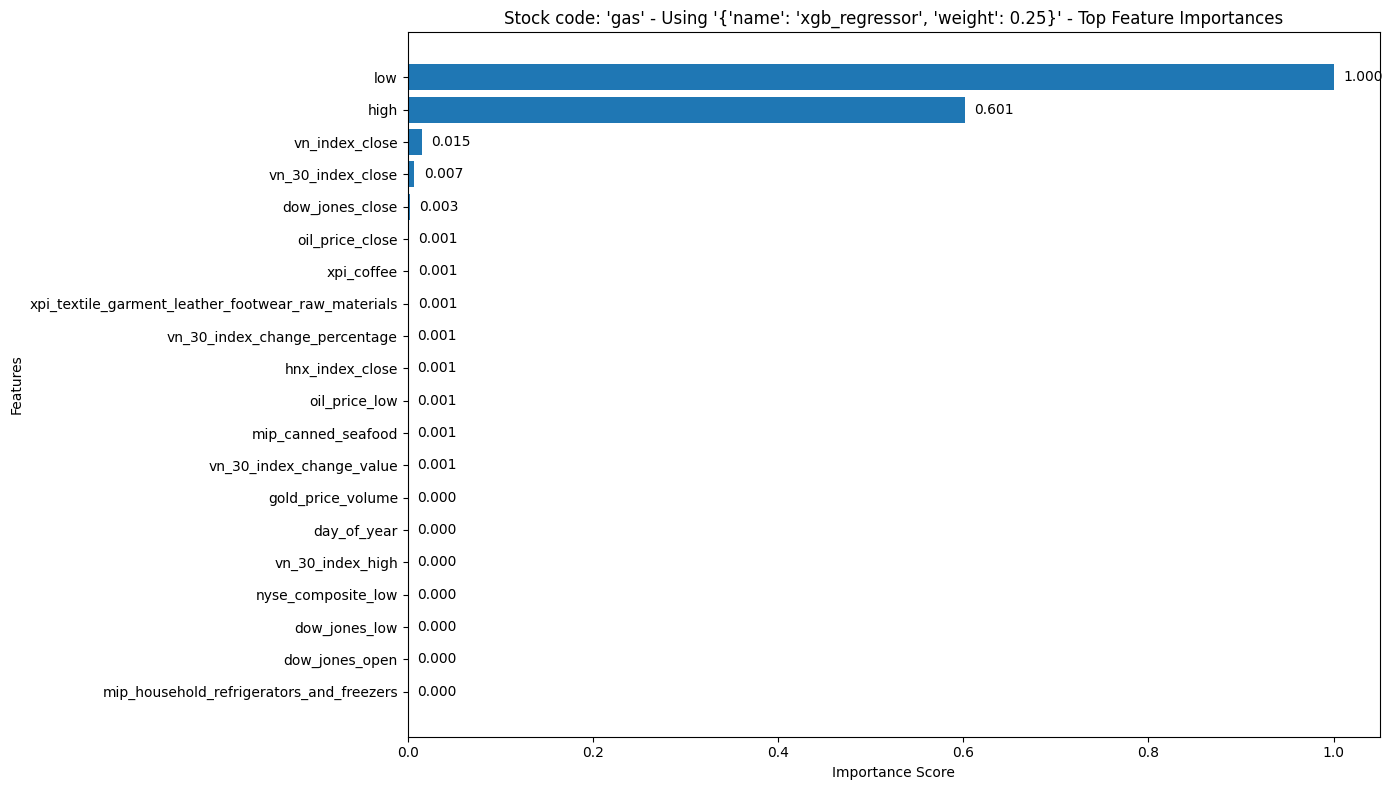

In [178]:
xgb_feature_selector.plot_feature_importances()

## Feature Selection Type: LASSO

In [179]:
lasso_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.LASSO,
)

In [180]:
lasso_feature_selector.fit(dataframe=train, target_column=output_column_name)

d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.452e+02, tolerance: 1.189e+02
  model = cd_fast.enet_coordinate_descent(


In [181]:
normalized_importances_dict[FeatureSelectorType.LASSO.value["name"]] = (
    lasso_feature_selector.get_feature_importances()
)
lasso_feature_selector.get_feature_importances()

,feature,importance
0,high,1.000000
1,open,0.213257
2,low,0.184839
3,vn_30_index_change_value,0.021768
4,mip_fired_tiles,0.002533
...,...,...
219,mip_domestic_ceramics,0.000000
220,mip_extracted_stone,0.000000
221,mip_fabric,0.000000
222,mip_fabric_shoes,0.000000


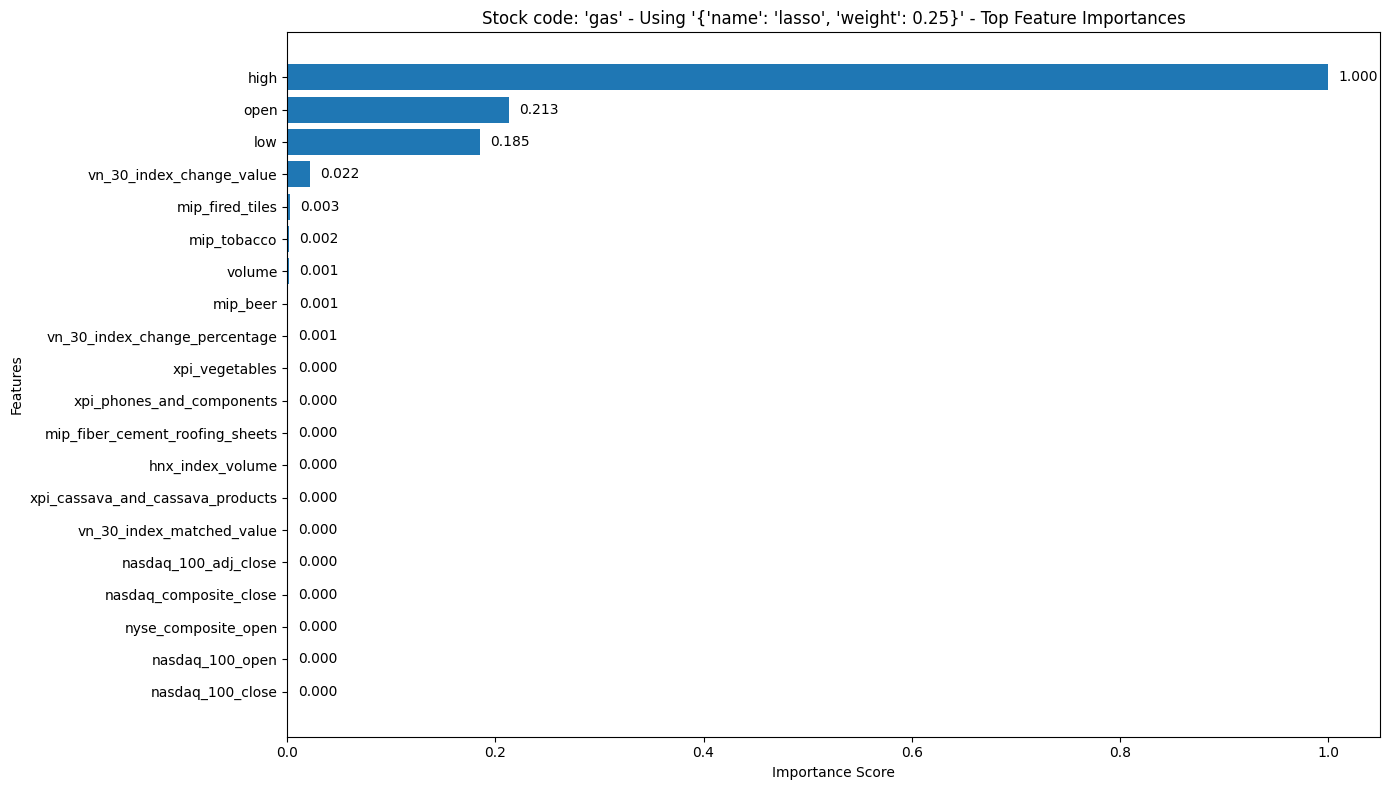

In [182]:
lasso_feature_selector.plot_feature_importances()

## Feature Selection Type: ELASTIC_NET

In [183]:
elastic_net_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.ELASTIC_NET,
)

In [184]:
elastic_net_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [185]:
normalized_importances_dict[FeatureSelectorType.ELASTIC_NET.value["name"]] = (
    elastic_net_feature_selector.get_feature_importances()
)
elastic_net_feature_selector.get_feature_importances()

,feature,importance
0,high,1.000000
1,low,0.967881
2,open,0.887970
3,vn_index_close,0.071140
4,mip_canned_seafood,0.061195
...,...,...
219,mip_granulated_sugar,0.000000
220,mip_gravel_and_pebbles,0.000000
221,mip_household_electric_fans,0.000000
222,mip_household_refrigerators_and_freezers,0.000000


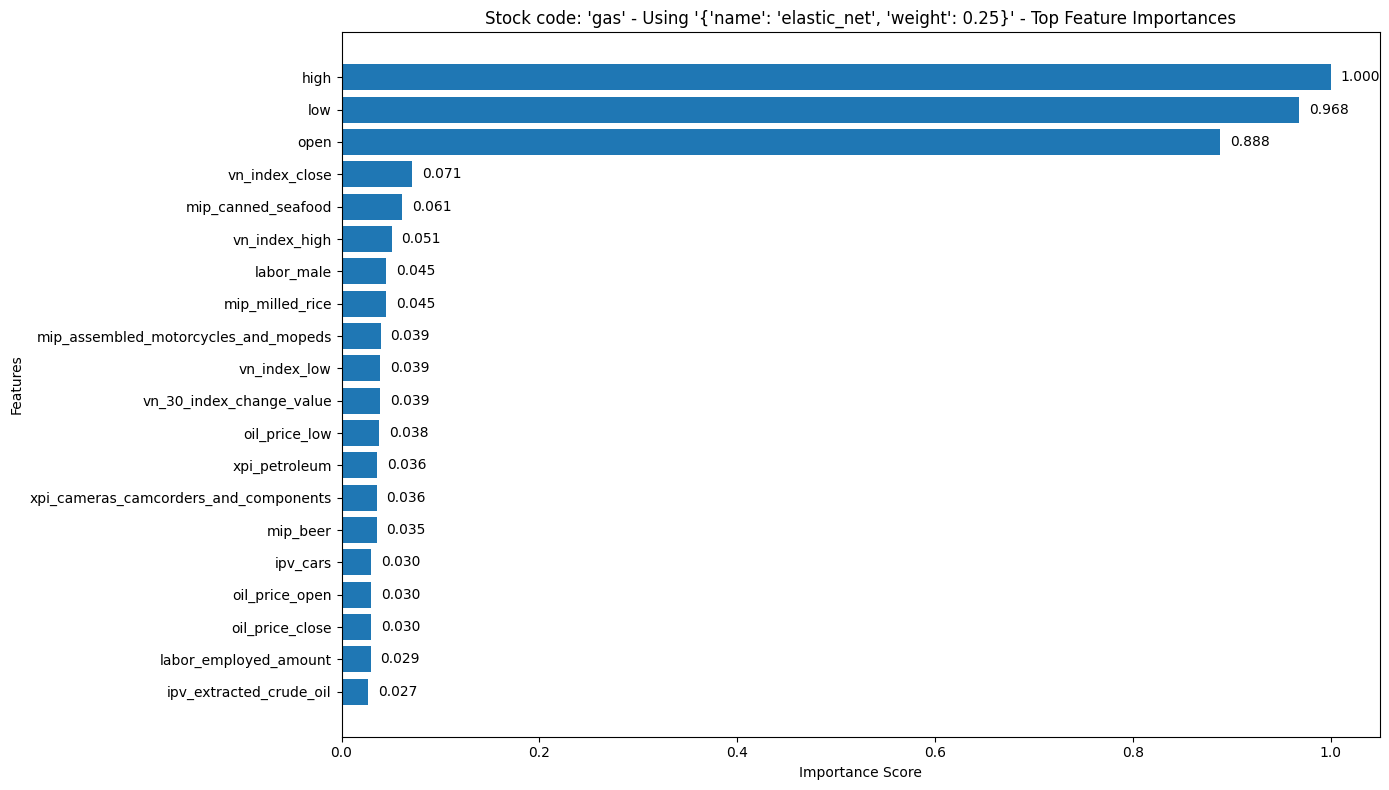

In [186]:
elastic_net_feature_selector.plot_feature_importances()

## Feature Selection Type: XGB_SHAP

In [187]:
xgb_shap_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.XGB_SHAP,
)

In [188]:
xgb_shap_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [189]:
normalized_importances_dict[FeatureSelectorType.XGB_SHAP.value["name"]] = (
    xgb_shap_feature_selector.get_feature_importances()
)
xgb_shap_feature_selector.get_feature_importances()

,feature,importance
0,low,1.000000
1,high,0.925642
2,vn_index_close,0.009398
3,vn_30_index_change_value,0.008949
4,vn_30_index_change_percentage,0.008782
...,...,...
219,mip_chemical_fertilizers,0.000000
220,mip_crude_oil_extraction,0.000000
221,mip_domestic_ceramics,0.000000
222,mip_fabric,0.000000


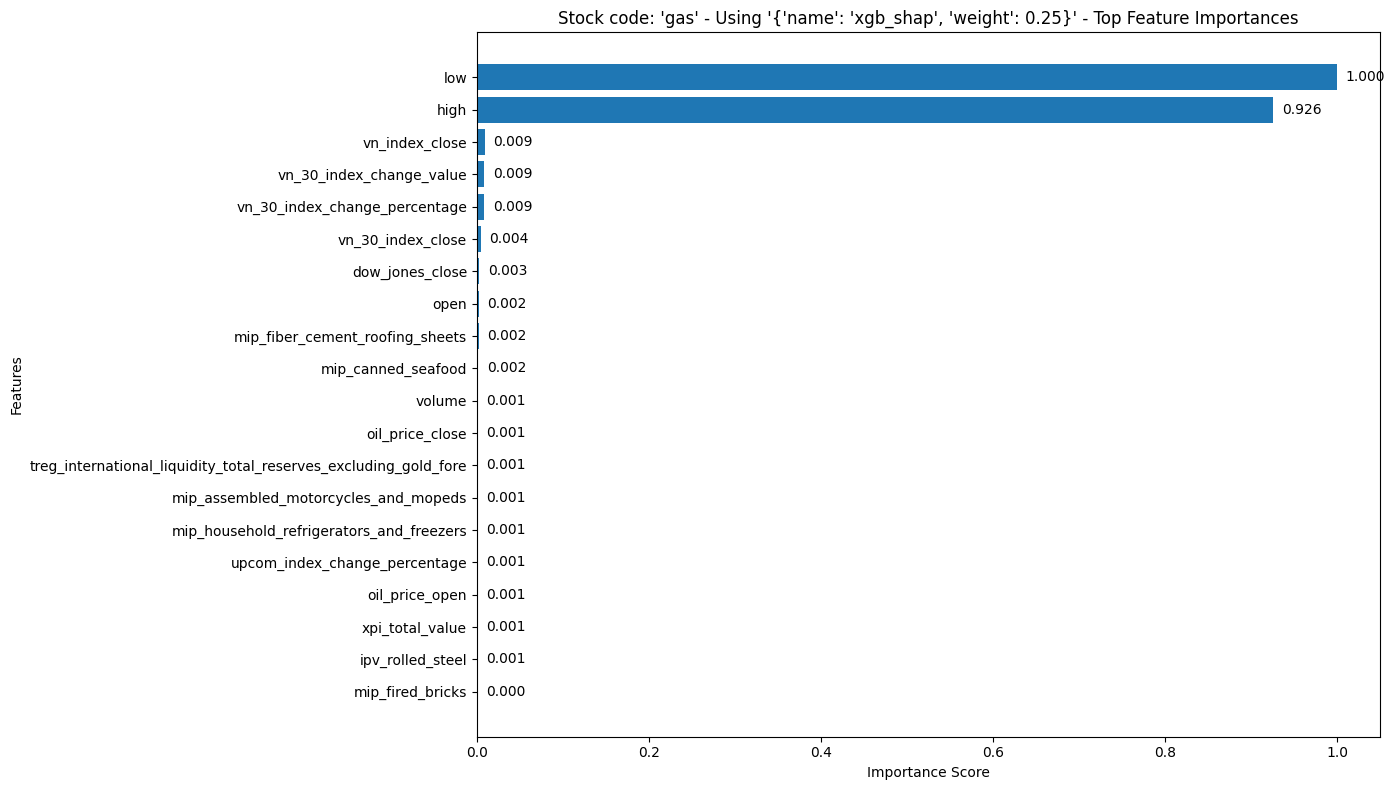

In [190]:
xgb_shap_feature_selector.plot_feature_importances()

## Normalize Feature Selection Types

In [191]:
weights = {
    FeatureSelectorType.XGB_REGRESSOR.value[
        "name"
    ]: FeatureSelectorType.XGB_REGRESSOR.value["weight"],
    FeatureSelectorType.LASSO.value["name"]: FeatureSelectorType.LASSO.value["weight"],
    FeatureSelectorType.ELASTIC_NET.value[
        "name"
    ]: FeatureSelectorType.ELASTIC_NET.value["weight"],
    FeatureSelectorType.XGB_SHAP.value["name"]: FeatureSelectorType.XGB_SHAP.value[
        "weight"
    ],
}
weights

{'xgb_regressor': 0.25, 'lasso': 0.25, 'elastic_net': 0.25, 'xgb_shap': 0.25}

In [192]:
final_feature_importance_df = summarize_feature_importances(
    normalized_importances_dict=normalized_importances_dict, weights=weights
)
final_feature_importance_df

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,high,0.601406,1.000000,1.000000,0.925642,0.150352,0.250000,0.250000,0.231410,0.881762
1,low,1.000000,0.184839,0.967881,1.000000,0.250000,0.046210,0.241970,0.250000,0.788180
2,open,0.000340,0.213257,0.887970,0.002445,0.000085,0.053314,0.221993,0.000611,0.276003
3,vn_index_close,0.015000,0.000000,0.071140,0.009398,0.003750,0.000000,0.017785,0.002350,0.023884
4,vn_30_index_change_value,0.000601,0.021768,0.039242,0.008949,0.000150,0.005442,0.009810,0.002237,0.017640
...,...,...,...,...,...,...,...,...,...,...
219,mip_processed_tea,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
220,mip_printed_newspapers_and_other_printing_prod...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
221,mip_pesticides,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
222,mip_natural_gas_in_gas_form,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\gas_final_feature_importances.png


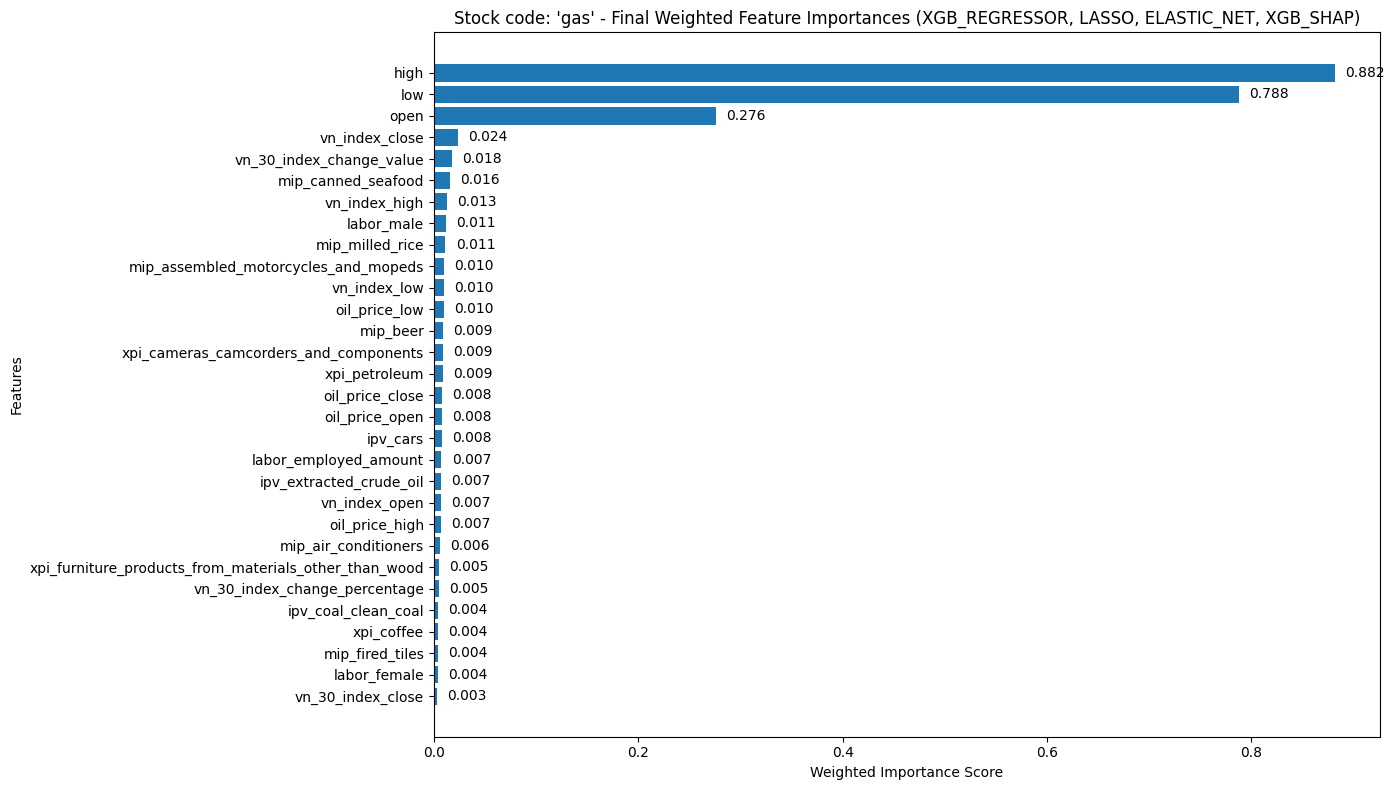

In [193]:
important_features_df = plot_final_feature_importances(
    stock_code=stock_code,
    combined_df=final_feature_importance_df,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [194]:
important_features_df = get_important_features_df(
    combined_df=final_feature_importance_df,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [195]:
important_features_df

,feature,final_importance
0,high,0.881762
1,low,0.788180
2,open,0.276003
3,vn_index_close,0.023884
4,vn_30_index_change_value,0.017640
5,mip_canned_seafood,0.015895
6,vn_index_high,0.012722
7,labor_male,0.011389
8,mip_milled_rice,0.011259
9,mip_assembled_motorcycles_and_mopeds,0.010105


In [196]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['high',
 'low',
 'open',
 'vn_index_close',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'vn_index_high',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'vn_index_low',
 'oil_price_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'xpi_petroleum',
 'oil_price_close',
 'oil_price_open',
 'ipv_cars',
 'labor_employed_amount',
 'ipv_extracted_crude_oil',
 'vn_index_open',
 'oil_price_high',
 'mip_air_conditioners',
 'xpi_furniture_products_from_materials_other_than_wood',
 'vn_30_index_change_percentage',
 'ipv_coal_clean_coal',
 'xpi_coffee',
 'mip_fired_tiles',
 'labor_female',
 'vn_30_index_close']

## Heatmap Visualization

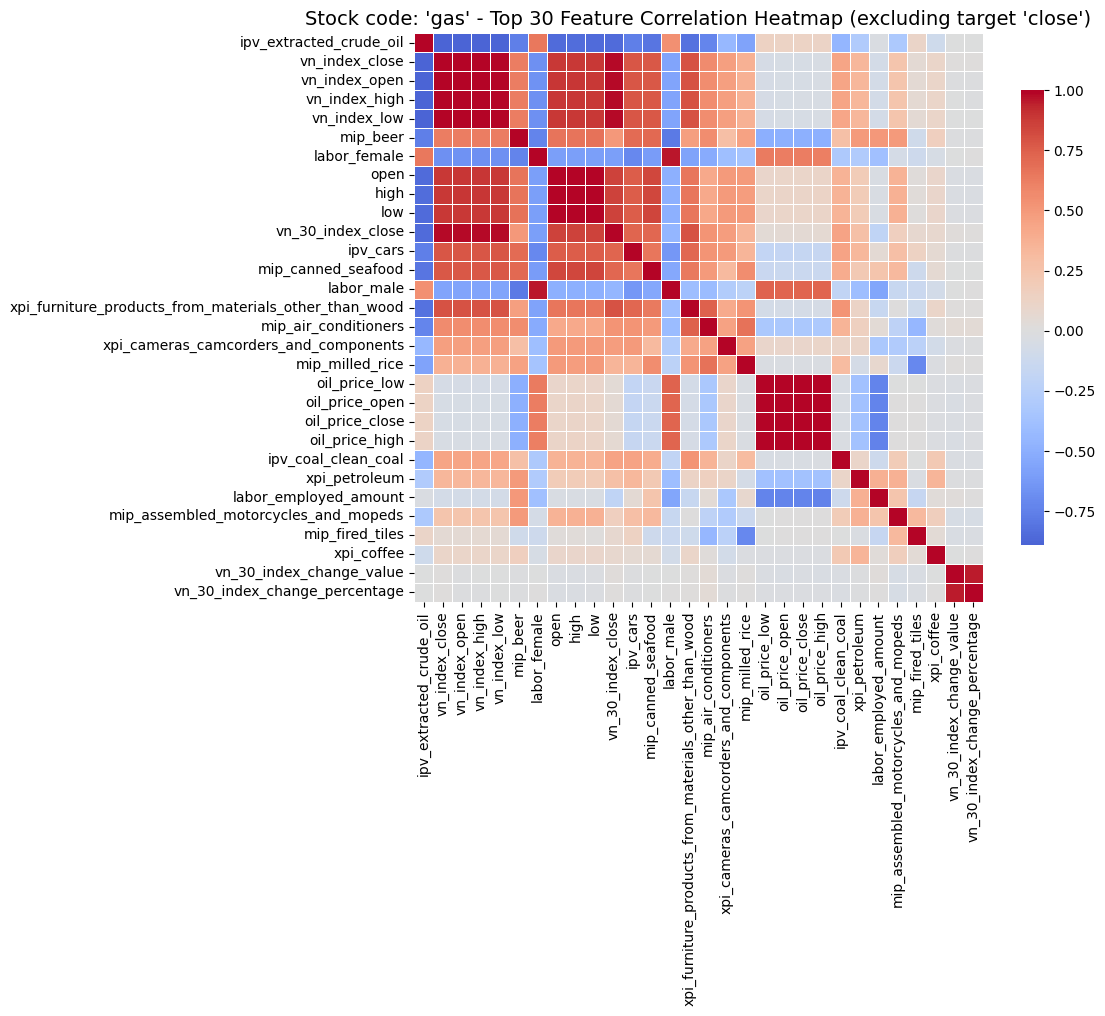

In [197]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [198]:
correlation_df = get_feature_correlation_df(
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [199]:
correlation_df

,feature_1,feature_2,corr
0,vn_index_open,vn_index_high,0.999816
1,vn_index_close,vn_index_low,0.999729
2,vn_index_close,vn_index_high,0.999705
3,vn_index_open,vn_index_low,0.999698
4,vn_index_high,vn_index_low,0.999616
5,vn_index_close,vn_index_open,0.999446
6,open,low,0.999335
7,open,high,0.999255
8,oil_price_low,oil_price_close,0.999254
9,oil_price_open,oil_price_high,0.999171


In [200]:
kept_features, dropped_features, pruned_importance_df = (
    drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 11 highly correlated features (|r| > 0.9):
['labor_female', 'low', 'oil_price_close', 'oil_price_high', 'oil_price_open', 'open', 'vn_30_index_change_percentage', 'vn_30_index_close', 'vn_index_high', 'vn_index_low', 'vn_index_open']
✅ Kept 19 features after pruning correlation redundancy.


In [201]:
kept_features

['high',
 'vn_index_close',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'oil_price_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'xpi_petroleum',
 'ipv_cars',
 'labor_employed_amount',
 'ipv_extracted_crude_oil',
 'mip_air_conditioners',
 'xpi_furniture_products_from_materials_other_than_wood',
 'ipv_coal_clean_coal',
 'xpi_coffee',
 'mip_fired_tiles']

In [202]:
dropped_features

['labor_female',
 'low',
 'oil_price_close',
 'oil_price_high',
 'oil_price_open',
 'open',
 'vn_30_index_change_percentage',
 'vn_30_index_close',
 'vn_index_high',
 'vn_index_low',
 'vn_index_open']

In [203]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 11 features


In [204]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,3.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,5.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


## Heatmap Visualization before + after feature selection

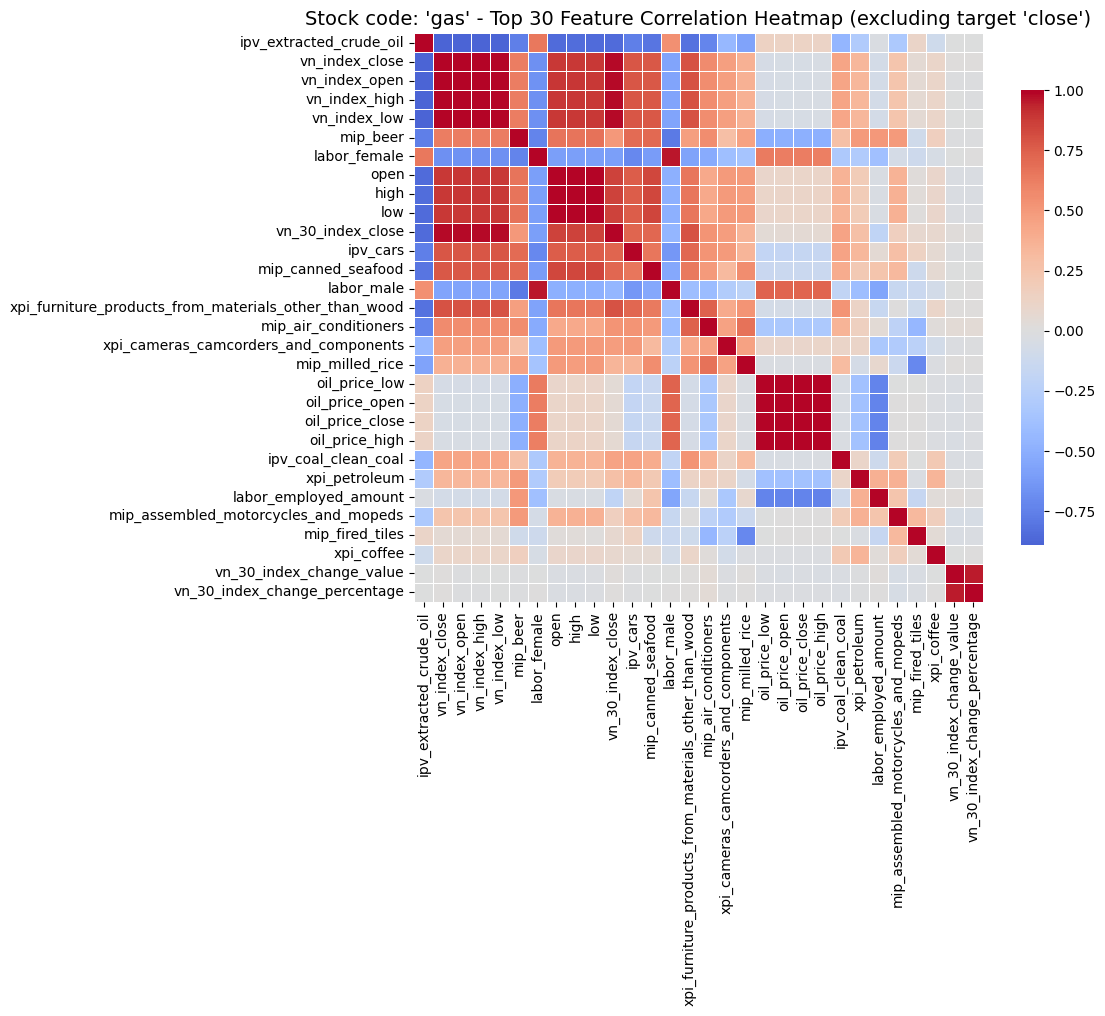

In [205]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

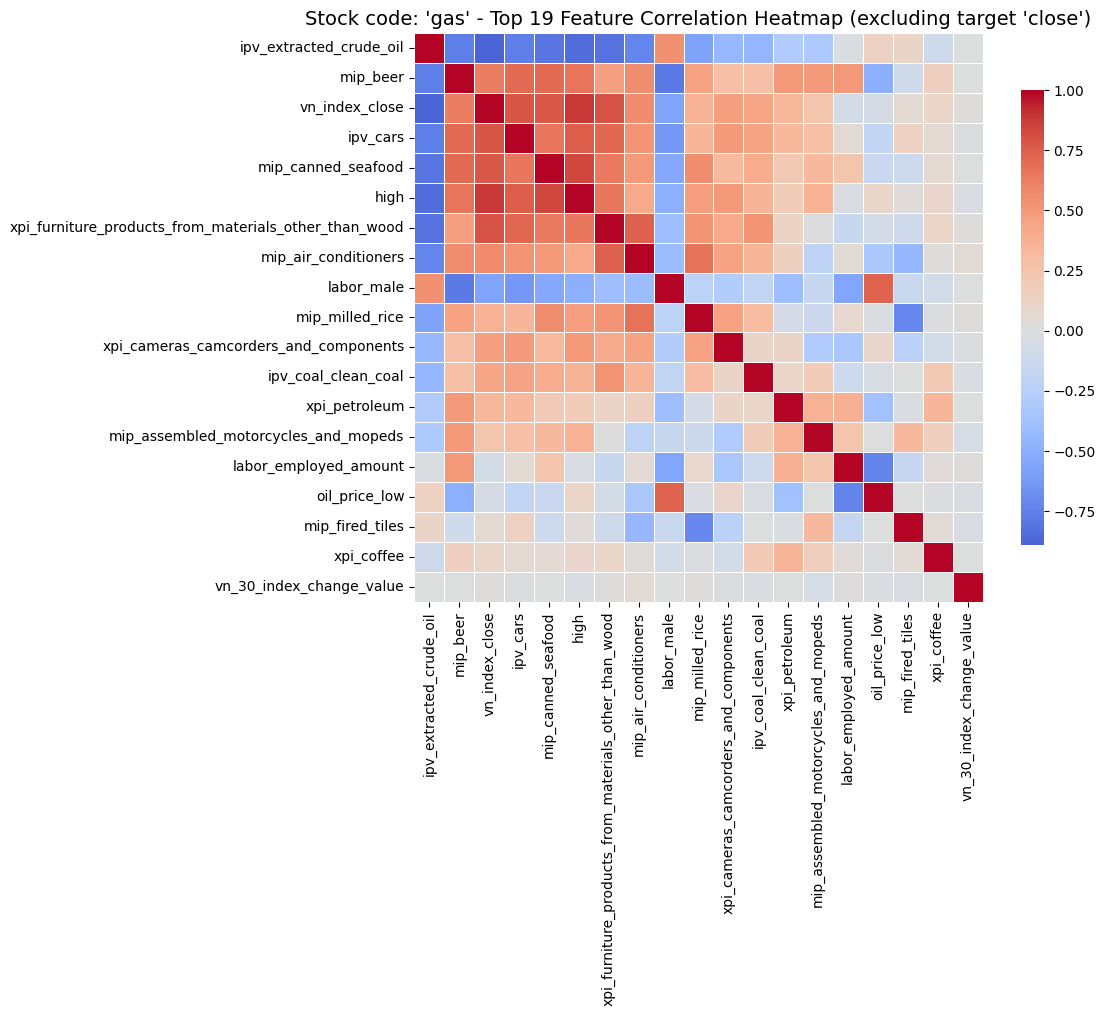

In [206]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=feature_selected_train,
    feature_columns=kept_features,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [207]:
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,3.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,4.0,1.0,0.0,2.0,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,4.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,5.0,1.0,0.0,1.0,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371
